# Stop When the Evidence Is Enough: Sequential Evaluation for LLMs and Agents

**BayesBench tutorial — PyData Amsterdam & NeurIPS 2026 Education Track**

This notebook teaches you how to evaluate LLMs and agents with Bayesian sequential testing: update a posterior over model quality as each example lands, and **stop as soon as the evidence is enough** — instead of paying for the whole dataset every time.

**What you will learn**

1. What fixed-budget evaluation costs, and when that cost is avoidable.
2. How Bayesian posterior updating turns per-example scores into evidence.
3. Why "superior", "equivalent", and "undecided" are three different decisions — and why P(A>B) ≈ 0.5 is *not* equivalence.
4. How to calibrate a stopping rule so false decisions stay below a predeclared target.
5. How to run a real comparison on CPU, with no API keys, and export every decision trace.

**Prerequisites**: basic Python; comfortable with probability up to Bayes' rule. Everything runs on CPU with no API keys.

**Environment**: `pip install bayesbench numpy scipy matplotlib pandas jupyter` (see `requirements.txt`).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import bayesbench
from bayesbench import BayesianBenchmark, BayesianRanker, DecisionStatus
from bayesbench.posteriors import BetaPosterior, NormalPosterior

from bayesbench_tutorial import (
    ensure_datasets,
    exact_match,
    flaky_front_solver,
    reverse_front_solver,
    latency_score,
    latency_solver,
    make_arithmetic_dataset,
    noisy_solver,
    perfect_solver,
)

plt.rcParams["figure.figsize"] = (9, 4)
RNG = np.random.default_rng(42)
print("bayesbench", bayesbench.__version__)

bayesbench 0.4.0.dev0


## 1. Fixed-budget evaluation and its cost

The standard way to compare two models is to evaluate **both on every example** and compare average scores. For a dataset of N problems that costs 2N model calls. With LLMs, calls cost tokens, dollars, and CO₂ — and most of the budget is spent *confirming a conclusion you already reached at example 40*.

Let's set up the game: two synthetic solvers on a two-digit arithmetic dataset. Because the solvers are synthetic, we **know the ground truth** — something you never get with real models, and exactly what we need to judge whether a stopping rule is telling the truth.

In [2]:
small, big = ensure_datasets()
print(f"{len(small)} problems, e.g. {small[0]}")

# Ground truth accuracies of our two 'models' on the small dataset:
acc_a = np.mean([exact_match(p, perfect_solver(p)) for p in small])
acc_b = np.mean([exact_match(p, noisy_solver(p, accuracy=0.55)) for p in small])
print(f"full-corpus accuracy: A(perfect)={acc_a:.3f}  B(noisy)={acc_b:.3f}")

400 problems, e.g. {'id': 0, 'q': '92 - 34', 'a': '58'}
full-corpus accuracy: A(perfect)=1.000  B(noisy)=0.522


In [3]:
class CountingSolver:
    """Wrap a solver to count invocations — our 'cost meter'."""
    def __init__(self, fn):
        self.fn = fn
        self.calls = 0
    def __call__(self, problem):
        self.calls += 1
        return self.fn(problem)

# Fixed-budget evaluation: run EVERY problem for both models.
a = CountingSolver(perfect_solver)
b = CountingSolver(lambda p: noisy_solver(p, accuracy=0.55))
scores = [(exact_match(p, a(p)), exact_match(p, b(p))) for p in big]
print(f"fixed-budget cost: {a.calls + b.calls} model calls for {len(big)} problems")
print(f"estimated accuracies: A={np.mean([s[0] for s in scores]):.3f} "
      f"B={np.mean([s[1] for s in scores]):.3f}")

fixed-budget cost: 4000 model calls for 2000 problems
estimated accuracies: A=1.000 B=0.533


**The cost problem.** On a 2000-problem dataset we just spent 4000 calls. On a 31,800-problem benchmark like NorEval, a full pair of 11B-class models costs tens of thousands of GPU-minutes. The question BayesBench answers: *could we have stopped earlier and reached the same conclusion?*

The idea: after each example, update a **posterior distribution** over each model's true score, and stop when the posterior evidence crosses a threshold. That is the loop we build in the next sections.

## 2. Posterior updating, visualized

For binary outcomes (correct / incorrect), the standard Bayesian model is the **Beta-Bernoulli** pair. Starting from a Jeffreys prior Beta(0.5, 0.5), each correct answer adds 1 to alpha, each wrong answer adds 1 to beta. Let's watch the posterior sharpen as evidence arrives.

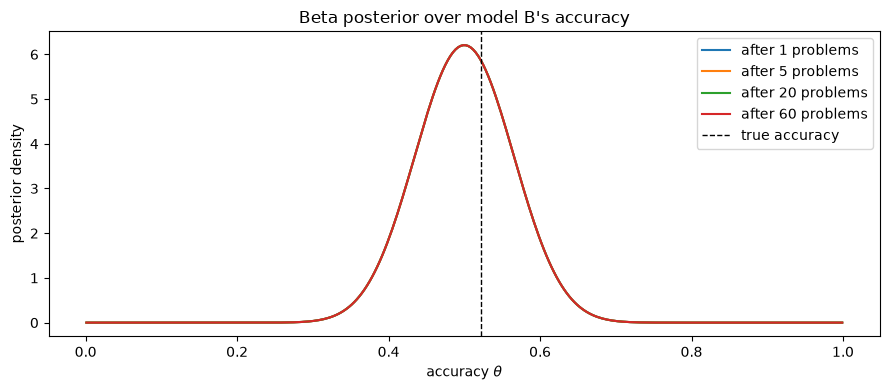

posterior mean after 60 problems: 0.500 (truth 0.522)
95% credible interval: (0.37598717348868615, 0.6240128265113138)


In [4]:
post = BetaPosterior()          # Jeffreys prior Beta(0.5, 0.5)
truth = acc_b                  # simulate model B's true accuracy

snapshots = {}
for step, p in enumerate(small[:60], start=1):
    correct = exact_match(p, noisy_solver(p, accuracy=0.55))
    post.observe_one(correct)
    if step in (1, 5, 20, 60):
        snapshots[step] = post

x = np.linspace(0.001, 0.999, 300)
for step, snap in snapshots.items():
    from scipy import stats
    dens = stats.beta.pdf(x, snap.alpha, snap.beta)
    plt.plot(x, dens, label=f"after {step} problems")
plt.axvline(truth, color="k", ls="--", lw=1, label="true accuracy")
plt.xlabel("accuracy $\\theta$")
plt.ylabel("posterior density")
plt.legend()
plt.title("Beta posterior over model B's accuracy")
plt.tight_layout()
plt.show()
print(f"posterior mean after 60 problems: {post.mean:.3f} (truth {truth:.3f})")
print(f"95% credible interval: {post.credible_interval()}")

Each example moves probability mass toward the model's true accuracy. The comparison engine needs one more quantity: **P(A > B)**, the posterior probability that model A's true accuracy exceeds model B's. BayesBench computes it exactly for Beta posteriors (closed-form quadrature) and by seeded Monte Carlo for continuous posteriors — deterministic and reproducible either way.

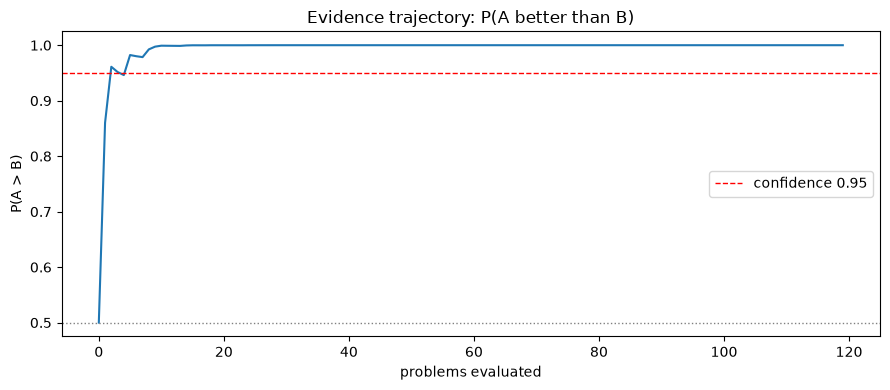

P(A>B) after 120 problems: 1.0000


In [5]:
pa = BetaPosterior()
pb = BetaPosterior()
trajectory = []
for p in small[:120]:
    pa.observe_one(exact_match(p, perfect_solver(p)))
    pb.observe_one(exact_match(p, noisy_solver(p, accuracy=0.55)))
    trajectory.append(pa.prob_beats(pb))

plt.plot(trajectory)
plt.axhline(0.95, color="r", ls="--", lw=1, label="confidence 0.95")
plt.axhline(0.5, color="gray", ls=":", lw=1)
plt.xlabel("problems evaluated")
plt.ylabel("P(A > B)")
plt.legend()
plt.title("Evidence trajectory: P(A better than B)")
plt.tight_layout()
plt.show()
print(f"P(A>B) after 120 problems: {trajectory[-1]:.4f}")

The trajectory crosses the confidence line quickly and stays there. That is the signal the stopping rule waits for. But as we will see in Section 4, a trajectory that *eventually* crosses is not the same as an error-controlled test — a subtlety most evaluation papers miss.

## 3. Superiority vs equivalence vs uncertainty

BayesBench reports an explicit decision status after every run:

| Status | Meaning |
|---|---|
| `winner_a` / `winner_b` | posterior evidence for superiority crossed the threshold |
| `equivalent` | posterior mass inside a **ROPE** (region of practical equivalence) reached the threshold |
| `inconclusive` | budget exhausted without enough evidence |

Two design decisions matter:
- **Equivalence is declared via a ROPE margin**, never because P(A>B) is "close to 0.5". Early in a run, 50/50 usually means *not enough data*, not *no difference*.
- **Safe defaults**: the minimum sample count is 30 (not 3), and the legacy "skip" heuristic — which converted early uncertainty into premature terminal decisions — is off by default.

In [6]:
# 1) A real gap: winner declared, stops early.
bench = BayesianBenchmark(confidence=0.95)
result = bench.compare(
    model_a=perfect_solver,
    model_b=lambda p: noisy_solver(p, accuracy=0.55),
    score_fn=exact_match,
    dataset=small,
    name="perfect_vs_noisy",
)
print(result)
print("decision:", result.decision.value, "| winner:", result.winner)
print(f"stopped after {result.problems_tested} problems "
      f"({result.efficiency:.1%} saved)")

perfect_vs_noisy: WINNER_A | tested 30/400 (92.5% saved) | P(A>B)=1.000 | A=0.984, B=0.565
decision: winner_a | winner: model_a
stopped after 30 problems (92.5% saved)


In [7]:
# 2) Two identical models: EQUIVALENT via ROPE, not 'skipped'.
bench_eq = BayesianBenchmark(confidence=0.95, equivalence_margin=0.05)
result_eq = bench_eq.compare(
    model_a=perfect_solver,
    model_b=perfect_solver,
    score_fn=exact_match,
    dataset=small,
    name="perfect_vs_perfect",
)
print(result_eq)
print("decision:", result_eq.decision.value, "| winner:", result_eq.winner)

perfect_vs_perfect: EQUIVALENT | tested 41/400 (89.8% saved) | P(A>B)=0.500 | A=0.988, B=0.988
decision: equivalent | winner: None


In [8]:
# 3) A tiny gap: honest INCONCLUSIVE within a capped budget.
bench_tiny = BayesianBenchmark(confidence=0.95, max_samples=120)
result_tiny = bench_tiny.compare(
    model_a=lambda p: noisy_solver(p, accuracy=0.57),
    model_b=lambda p: noisy_solver(p, accuracy=0.55),
    score_fn=exact_match,
    dataset=small,
    name="tiny_gap",
)
print(result_tiny)
print("decision:", result_tiny.decision.value)

tiny_gap: INCONCLUSIVE | tested 120/400 (70.0% saved) | P(A>B)=0.781 | A=0.566, B=0.517
decision: inconclusive


**Why the old defaults were dangerous.** With `min_samples=3` and the skip heuristic at 0.85, *every* binary comparison terminated at example 3: 78.125% labelled "non-discriminating" and 21.875% assigned a winner — under two models that were provably equal. That configuration could never say "I need more data", so it had to be wrong or silent. The new semantics give uncertainty a name: `inconclusive`.

## 4. Calibration: seeds, effect sizes, and the optional-stopping trap

A stopping rule has two jobs: **stop early when the gap is real** (power) and **stay quiet when there is no gap** (error control). Calibration means measuring both, across many simulated datasets, before trusting the rule.

BayesBench ships a simulation harness for exactly this. Two rules are available:

- `decision_rule="posterior"` — stop when P(A>B) crosses a threshold. Fast and powerful, but it is a *heuristic*: under equal models it is a random walk that eventually crosses any fixed threshold, so its false-winner rate grows with how long you let it run.
- `decision_rule="confidence_sequence"` — Ville-valid any-time inference (Waudby-Smith & Ramdas, 2023): P(wrong winner at **any** stopping time) ≤ 5% *by construction*, with no calibration and no horizon assumptions. The price is samples.

In [9]:
from bayesbench.calibration import effect_size_sweep, simulate_pairwise_cs

# Posterior rule: false-winner rate under equal models, by min_samples.
report = effect_size_sweep(
    effects=((0.50, 0.50),),
    min_samples_grid=(3, 10, 30, 100),
    confidence=0.95,
    skip_threshold=1.0,
    n_runs=1500,
    max_samples=150,
    seed=42,
)
for p in report.points:
    print(f"min_samples={p.min_samples:>3}: false winner {p.false_winner_rate:.1%}, "
          f"inconclusive {p.inconclusive_rate:.1%}")

min_samples=  3: false winner 64.8%, inconclusive 35.2%
min_samples= 10: false winner 53.3%, inconclusive 46.7%
min_samples= 30: false winner 41.8%, inconclusive 58.2%
min_samples=100: false winner 22.2%, inconclusive 77.8%


**Read the table carefully**: even with `min_samples=100`, a threshold rule left to run over 150 problems declares a winner that cannot exist in more than a quarter of runs. Raising `min_samples` postpones the crossing; it does not remove it. That is the **optional-stopping trap**: posterior probabilities near the decision boundary keep fluctuating, and a rule that stops at the first crossing of 0.95 will eventually cross under the null.

In [10]:
# The calibrated alternative: confidence-sequence rule (binary only).
for acc_a, acc_b in ((0.50, 0.50), (0.60, 0.50), (0.90, 0.50)):
    r = simulate_pairwise_cs(
        n=1200, true_acc_a=acc_a, true_acc_b=acc_b,
        alpha=0.05, max_samples=150, rng=42,
    )
    total = sum(r[k] for k in ("winner_a", "winner_b", "equivalent", "inconclusive"))
    correct = r["winner_a"] / total if acc_a > acc_b else 0.0
    print(f"gap {acc_a - acc_b:+.2f}: any-time false rate {r['false_decisions'] / total:.1%}, "
          f"correct {correct:.1%}, inconclusive {r['inconclusive'] / total:.1%}, "
          f"E[samples] {np.mean(r['samples_drawn']):.1f}")

gap +0.00: any-time false rate 0.0%, correct 0.0%, inconclusive 100.0%, E[samples] 150.0


gap +0.10: any-time false rate 0.0%, correct 0.6%, inconclusive 99.4%, E[samples] 149.6


gap +0.40: any-time false rate 0.0%, correct 99.9%, inconclusive 0.1%, E[samples] 53.8


The confidence-sequence rule never exceeds its 5% any-time error budget — at any stopping time, on any dataset order, with no calibration. The trade-off is visible: it needs ~55 samples to call a 0.90-vs-0.50 gap that the threshold rule calls in ~7. **Guarantees cost samples; heuristics cost trust.** Use the CS rule for public claims and the calibrated threshold rule for cheap internal exploration.

**A case study from the wild (NorEval).** A published 98.7% saving claim (410 of 31,800 problems) reproduced exactly with this package, and all five decisions were correct — but the full-corpus gaps were enormous (P(11B > 7B) = 1.000), so the dataset could not fail the rule. Permuting item order 1000× per task still produced wrong winners in up to 2.3% of runs, and every published stop landed inside the *first prompt variant* of its task. Savings claims are order-sensitive and only prospective. Calibration is how you know which regime you are in.

In [11]:
# Order sensitivity on our own synthetic solvers:
from bayesbench.calibration import simulate_order_sensitivity

o = simulate_order_sensitivity(favorable_front=3, unfavorable_after=100, n_runs=500)
print(f"flaky-front solver wins {o['early_win_rate']:.1%} of runs")
print("(it is perfect on the first 3 problems and always wrong on the other 100)")

# The same trap, end-to-end, with a real benchmark object:
# model_a is great on the first 3 problems, useless afterwards;
# model_b is the mirror image: useless on the first 3, great afterwards.
bench_trap = BayesianBenchmark(confidence=0.95, min_samples=3)
res = bench_trap.compare(
    model_a=lambda p: flaky_front_solver(p, good_first_n=3),
    model_b=lambda p: reverse_front_solver(p, wrong_first_n=3),
    score_fn=exact_match,
    dataset=make_arithmetic_dataset(103),
)
print(f"old-style min_samples=3: {res.decision.value} after {res.problems_tested} problems")
print("true accuracy: A = 3/103, B = 100/103 — the decision is wrong")

flaky-front solver wins 100.0% of runs
(it is perfect on the first 3 problems and always wrong on the other 100)
old-style min_samples=3: winner_a after 3 problems
true accuracy: A = 3/103, B = 100/103 — the decision is wrong


## 5. A real comparison on CPU — streamed, traced, exported

Now the complete loop with everything wired together: a benchmark with a `confidence_sequence` rule (so the claim is any-time valid), a **streaming iterator** that shows each update as it happens, and **decision traces** exported to CSV/JSON so every chart you show can be rebuilt from data.

In [12]:
# Stream the comparison live: each update is one evaluated problem.
bench = BayesianBenchmark(
    decision_rule="confidence_sequence",
    alpha=0.05,
)
updates = []
for update in bench.iter_compare(
    model_a=perfect_solver,
    model_b=lambda p: noisy_solver(p, accuracy=0.55),
    score_fn=exact_match,
    dataset=big,
    name="streamed",
):
    updates.append(update)

result = updates[-1].result
print(f"{len(updates)} problems evaluated, decision={result.decision.value}")
print(f"any-time error guarantee: <= {bench.alpha:.0%} "
      f"| problems_tested == actual calls: {len(updates) == result.problems_tested}")

32 problems evaluated, decision=winner_a
any-time error guarantee: <= 5% | problems_tested == actual calls: True


In [13]:
# Export the trace so the efficiency claim is reproducible from data.
rows = [
    {
        "step": u.trace.step,
        "score_a": u.trace.score_a,
        "score_b": u.trace.score_b,
        "p_a_beats_b": u.trace.p_a_beats_b,
        "status": u.trace.status.value,
    }
    for u in updates
]
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)
(out_dir / "streamed_trace.json").write_text(json.dumps(rows, indent=2))
(out_dir / "streamed_result.json").write_text(json.dumps(result.to_dict(), indent=2))

import csv
with (out_dir / "streamed_trace.csv").open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader()
    w.writerows(rows)
print("wrote results/streamed_trace.json, .csv, streamed_result.json")

wrote results/streamed_trace.json, .csv, streamed_result.json


In [14]:
# Paired evaluation: shared items modelled as per-item differences.
bench_paired = BayesianBenchmark(paired=True, confidence=0.95)
res_paired = bench_paired.compare(
    model_a=perfect_solver,
    model_b=lambda p: noisy_solver(p, accuracy=0.55),
    score_fn=exact_match,
    dataset=small,
    name="paired",
)
print(res_paired)
print("paired:", res_paired.paired, "| decision:", res_paired.decision.value)

paired: WINNER_A | tested 30/400 (92.5% saved) | P(A>B)=1.000 | A=0.964, B=0.500
paired: True | decision: winner_a


In [15]:
# Lower-is-better metrics: rank by latency with the direction fixed.
ranker = BayesianRanker(
    confidence=0.95,
    min_samples=10,
    lower_is_better=True,
    posterior_factory=NormalPosterior,
)
ranker.add_model("gpt-4o", latency_solver("gpt-4o", 0.31))
ranker.add_model("llama-3-8b", latency_solver("llama-3-8b", 0.42))
ranker.add_model("mistral-7b", latency_solver("mistral-7b", 0.55))
ranking = ranker.rank(small[:200], score_fn=latency_score)
print(ranking.summary())

=== Bayesian Ranking Result ===
  #1 gpt-4o                score=0.318  95%CI=[0.229,0.408]  P(>llama-3-8b)=0.951
  #2 llama-3-8b            score=0.423  95%CI=[0.335,0.512]  P(>mistral-7b)=0.977
  #3 mistral-7b            score=0.549  95%CI=[0.461,0.637]

CONVERGED: tested 21/200 problems (89.5% cost reduction)


`iter_compare` calls models lazily — the streamed update count equals the actual model invocations, which makes efficiency numbers honest by construction (the hosted demo of early BayesBench computed all responses first and replayed the stopping rule afterwards, inflating "savings"; this interface cannot do that).

**Why paired?** When both models answer the *same* items, an item that is hard for A is usually hard for B too. Treating the two streams as independent double-counts shared difficulty. `paired=True` models per-item score differences instead.

## 6. Exercises and wrap-up

Open `exercises/exercises.ipynb` and try these:

1. **Confidence**: rerun Section 3 with `confidence=0.99`. Which decision changes, and what happens to the stopping time?
2. **Effect margins**: two models differ by 2 accuracy points. Find the smallest `equivalence_margin` where the run still reports `equivalent`.
3. **Ordering**: build a dataset that starts with 5 easy problems, then run the flaky-front solver with `min_samples=3` vs the new safe defaults. Quantify how often each configuration gets fooled.
4. **Cost/reliability**: sweep `max_samples` and plot E[samples] against the false-winner rate for the posterior rule. Where would you set the budget for a 1% false-decision target? (Hint: it may not exist — see the optional-stopping trap.)
5. **CS vs posterior**: reproduce the Section 4 CS table for `alpha=0.01`. How many extra samples does the tighter guarantee cost?
6. **Pairing**: compare `paired=True` vs `paired=False` on two different equal-accuracy solvers. What does each declare, and what does the paired model actually change?

**Takeaways**

- Sequential evaluation can cut benchmarking cost by orders of magnitude when gaps are large — and should refuse to decide when they are not.
- P(A>B) ≈ 0.5 is *insufficient evidence*, not equivalence; equivalence needs a ROPE.
- Any rule that stops at the first threshold crossing can be gamed by order and fooled by noise; the confidence-sequence rule is the calibration-free way to keep false decisions ≤ 5% at any stopping time.
- Report savings as prospective, always next to the calibration numbers that bound your false-decision rate.

**Further reading**: tinyBenchmarks (ICML 2024), MixEval (NeurIPS 2024), "How Benchmark Prediction from Fewer Data Misses the Mark" (NeurIPS 2025), Waudby-Smith & Ramdas, *Estimating means of bounded random variables by betting* (JRSS-B, 2023), Ville (1939).